# Fourier Transform Tutorial Series — Roadmap and Quick Demo

These notebooks are a practical companion to James V. Stone's *The Fourier Transform: A Tutorial Introduction*. They are written to be run, modified, and experimented with.

**Attribution and use note.** The source book is by James V. Stone and is available under CC BY-NC-SA 4.0. These notebooks are an educational, non-commercial tutorial derived from the ideas and chapter structure of the book, with original examples and code.

## Mental model

A signal in time is like a finished meal. A Fourier transform is the recipe: it tells you which sinusoidal ingredients are present, how much of each ingredient is present, and where each one starts in phase.

The inverse Fourier transform uses the recipe to rebuild the meal.

## Notebook map

| Notebook | Main idea |
|---|---|
| 00 | Roadmap, setup, and a quick Fourier demo |
| 01 | Waves, radians, frequency, phase, amplitude |
| 02 | Mixing waves and building functions from harmonics |
| 03 | Unmixing with inner products and real Fourier coefficients |
| 04 | Discrete Fourier transform, FFT, frequency bins, leakage |
| 05 | Complex numbers, Euler's theorem, rotating waves |
| 06 | Complex Fourier transform and Fourier pairs |
| 07 | Sampling, aliasing, Parseval, shift, convolution |
| 08 | Gaussian transforms, uncertainty, time-frequency tradeoff, information |
| 09 | Two-dimensional Fourier transforms and images |
| 10 | Applications: filtering, deconvolution, diffraction, crystallography |

Run all cells in order. The plots are part of the explanation, not decoration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Quick demo: make a complicated-looking signal from three sinusoids

We will create a signal from three sinusoidal components. Then we will use an FFT to recover the component frequencies.

The important idea is that the time plot and the frequency plot contain the same information in different coordinates.

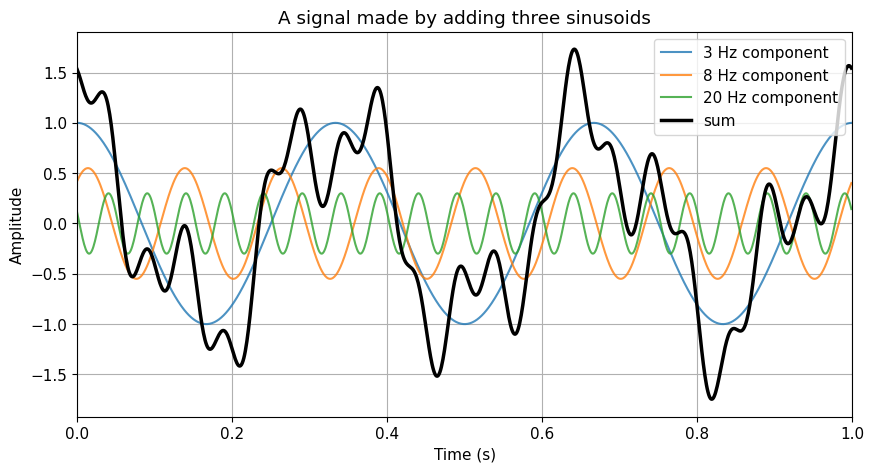

In [2]:
R = 1000          # samples per second
T = 1.0           # seconds
N = int(R*T)
t = np.arange(N) / R

components = [
    # frequency Hz, amplitude, phase radians
    (3, 1.00, 0.00),
    (8, 0.55, 0.70),
    (20, 0.30, -1.20),
]

parts = []
for f, A, phi in components:
    parts.append(A * np.cos(2*np.pi*f*t - phi))

x = np.sum(parts, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
for part, (f, A, phi) in zip(parts, components):
    ax.plot(t, part, alpha=0.8, label=f"{f} Hz component")
ax.plot(t, x, linewidth=2.5, label="sum", color="black")
ax.set_xlim(0, 1)
ax.set_title("A signal made by adding three sinusoids")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend(loc="upper right")
plt.show()

## The Fourier recipe

The amplitude spectrum answers: **how much of each frequency is present?**

For a real-valued signal, `np.fft.rfft` returns the nonnegative frequency bins from 0 up to the Nyquist frequency.

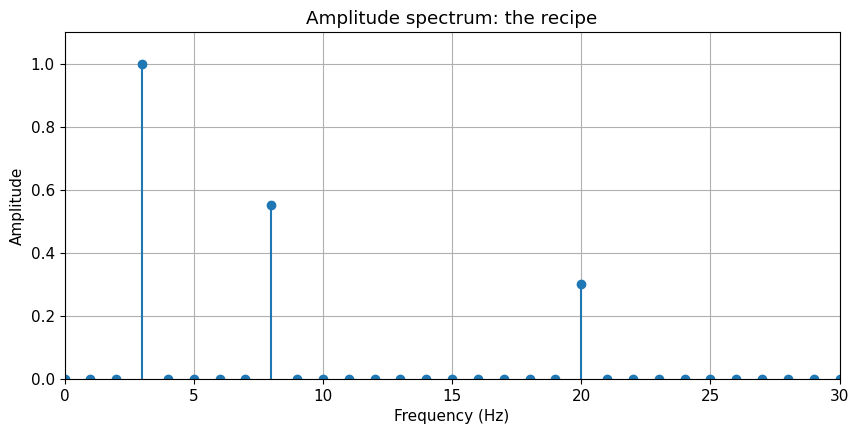

In [3]:
X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(N, d=1/R)

amplitude = 2*np.abs(X)/N
amplitude[0] = np.abs(X[0])/N

fig, ax = plt.subplots(figsize=(10, 4.5))
markerline, stemlines, baseline = ax.stem(freqs, amplitude, basefmt=" ")
ax.set_xlim(0, 30)
ax.set_ylim(0, 1.1)
ax.set_title("Amplitude spectrum: the recipe")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
plt.show()

## Rebuild using only the three largest Fourier components

The inverse transform turns frequency-domain coefficients back into a time-domain signal.

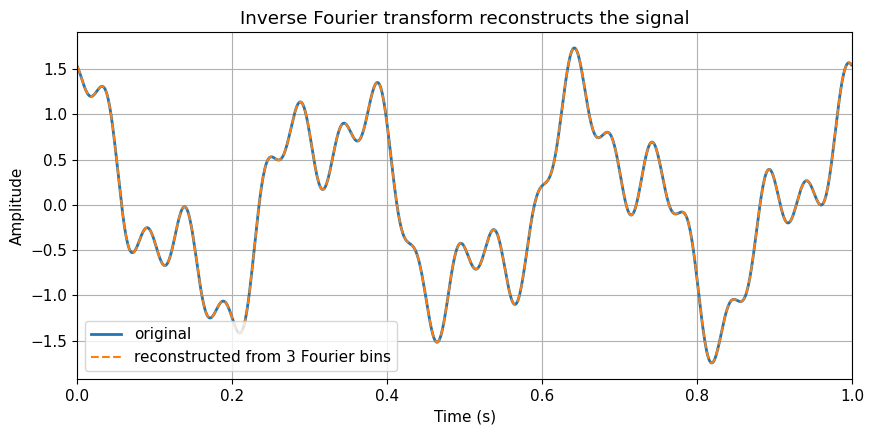

Kept frequency bins: [20.  8.  3.] Hz
Maximum reconstruction error: 7.771561172376096e-15


In [4]:
X_keep = np.zeros_like(X)
# Ignore DC when choosing the largest oscillatory components.
nonzero_bins = np.arange(1, len(X))
top = nonzero_bins[np.argsort(np.abs(X[1:]))[-3:]]
X_keep[top] = X[top]

x_reconstructed = np.fft.irfft(X_keep, n=N)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, x, label="original", linewidth=2)
ax.plot(t, x_reconstructed, "--", label="reconstructed from 3 Fourier bins")
ax.set_xlim(0, 1)
ax.set_title("Inverse Fourier transform reconstructs the signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

print("Kept frequency bins:", freqs[top], "Hz")
print("Maximum reconstruction error:", np.max(np.abs(x - x_reconstructed)))

## Checkpoint

1. Change the 20 Hz component to 23 Hz. What changes in the spectrum?
2. Add a constant offset `+ 1.5` to `x`. Which Fourier bin changes?
3. Change one phase. Does the amplitude spectrum change? Does the time waveform change?

The rest of the series explains why these observations happen.